© Copyright, 2025 G. Schaer.

SPDX-License-Identifier: GPL-3.0-only

# Simulator Example

This module provides an example usage case of the Simulator class. Here we
simulate a cart with an inverted pendulum atop it. Because this is just an
example for the Simulator, no visualization is included.

In [1]:
import time
from condynsate import Simulator
from condynsate import __assets__ as assets
import matplotlib.pyplot as plt
# This is required so that matplotlib plots plot in the notebook
%matplotlib inline

To start, we will create an instance of the simulator with the default gravity and time step.

In [2]:
sim = Simulator()

Next we will load some objects into the simulator. The first is a simple plane that will be the floor on which a cart will roll. 

In [3]:
# Load a plane for the ground. This this case, fixed means that the
# base of the ground will not be affected by external forces
ground = sim.load_urdf(assets['plane_big.urdf'], fixed=True)

Next we add the cart. In this case, the cart is balancing an inverted pendulum on top of it. The angle of the pendulum is defined by `chassis_to_arm` joint.

In [4]:
# Add the cart from the default condynsate assets to the simulator.
cart = sim.load_urdf(assets['cart.urdf']) #return 0 on success

# Set its initial position such that the wheels start 0.001 meters above
# The ground plane
cart.set_initial_state(position=(0,0,0.251)) #return 0 on success

# Set the pendulum joint to some non-zero initial angle
cart.joints['chassis_to_arm'].set_initial_state(angle=0.001) #return 0 on success

0

Next we will run a simulation. In this simulation we will 
1. Keep track of the angle of the pendulum, the position of the cart, and the simulation time
2. Apply a small force in the -x direction to the center of mass of the cart
3. Take a simulation step

 When the simulation is done, we print to the screen how long it took. Because `real_time` is set to false in `sim.step`, the simulator will attempt to run as quickly as possible.

In [5]:
# Run a 5 second simulation loop
start = time.time()
pendulum_angle = []
cart_x_pos = []
simtime = []
while sim.time < 5.0:
    # Note the angle of the pendulum joint at each time step
    # Note the x coordinate of the cart at each time step
    # Note the simulation time at each step
    pendulum_angle.append(cart.joints['chassis_to_arm'].state.angle)
    cart_x_pos.append(cart.state.position[0])
    simtime.append(sim.time)

    # Apply a small force the the center of mass of the cart
    cart.apply_force((-0.025, 0.0, 0.0))

    # Attempt a simulation step. If something has gone wrong,
    # break the simulation loop
    if sim.step(real_time=False) != 0:
        break

# Note the terminate angle, position, and time
pendulum_angle.append(cart.joints['chassis_to_arm'].state.angle)
cart_x_pos.append(cart.state.position[0])
simtime.append(sim.time)

# Print how long the simulation took in real time
print(f"Simulation took: {(time.time() - start):.2f} seconds")

Simulation took: 0.23 seconds


When done, the terminate command will ensure graceful exit of all children threads

In [6]:
sim.terminate()

0

Finally, we will plot the results of the simulation

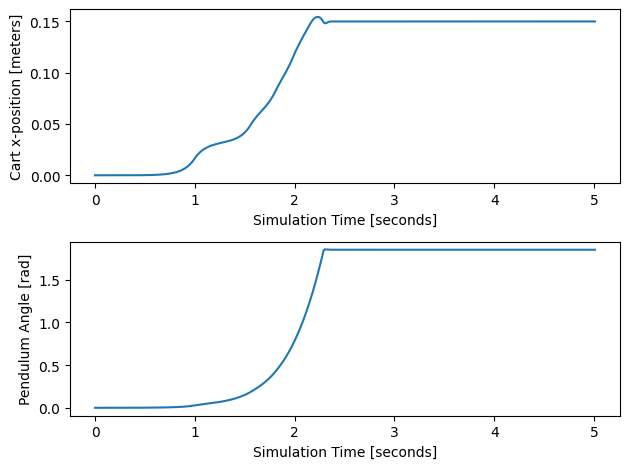

In [7]:
# Plot the results
fig, axes = plt.subplots(nrows=2,ncols=1)
axes[0].plot(simtime, cart_x_pos)
axes[0].set_xlabel('Simulation Time [seconds]')
axes[0].set_ylabel('Cart x-position [meters]')
axes[1].plot(simtime, pendulum_angle)
axes[1].set_xlabel('Simulation Time [seconds]')
axes[1].set_ylabel('Pendulum Angle [rad]')
fig.tight_layout()
plt.show()